In [81]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from IPython.display import clear_output
from tqdm import tqdm
import math
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [82]:
### загрузка датасета + трансформер сразу + создание даталоадеров
mnist_transforms = T.Compose(
    [
        T.Resize([32,32]),
        T.ToTensor(),
    ]
)
train_dataset = MNIST('../DL_7/mnist', train=True, transform = mnist_transforms, download = False)
valid_dataset = MNIST('../DL_7/mnist', train=False, transform = mnist_transforms, download = False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False, num_workers=8, pin_memory=True)

In [83]:
#!g1.1
def train(model):
    model.train()

    train_loss = 0

    for x, _ in tqdm(train_loader, desc='Train'): ### нужен только объект, т.е. x
        x = x.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, x)

        train_loss += loss.item()

        loss.backward()

        optimizer.step()

    train_loss /= len(train_loader)

    return train_loss

In [84]:
#!g1.1
@torch.inference_mode()
def evaluate(model, loader):
    model.eval()

    total_loss = 0

    for x, _ in tqdm(loader, desc='Evaluation'):
        x = x.to(device)

        output = model(x)

        loss = loss_fn(output, x)

        total_loss += loss.item()

    total_loss /= len(loader)

    return total_loss

In [85]:
#!g1.1
def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()
    plt.grid()

    plt.show()

In [86]:
#!g1.1
from torchvision.utils import make_grid


@torch.inference_mode()
def visualize(model, xs):
    model.eval()

    to_pil = T.ToPILImage()

    outputs = model(xs.to(device)).cpu()
    
    plt.figure(figsize=(20, 4))
    
    plt.imshow(
        to_pil(
            torch.cat(
                (
                    make_grid(xs[:10], nrow=10, pad_value=1),        ### 10 картинок в 1-ом ряду
                    make_grid(outputs[:10], nrow=10, pad_value=1)    ### 10 картинок в 2-ом ряду
                ),
                dim=1
            )
        )
    )
    
    plt.axis('off')

    plt.show()

In [87]:
#!g1.1
def whole_train_valid_cycle(model, num_epochs, title):
    train_loss_history, valid_loss_history = [], []

    for epoch in range(num_epochs):
        train_loss = train(model)
        valid_loss = evaluate(model, valid_loader)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        clear_output(wait=True)
        
        visualize(model, next(iter(valid_loader))[0])

        plot_stats(
            train_loss_history, valid_loss_history,
            title
        )

In [88]:
def save_embeddings(x_train, y_train, x_valid, y_valid):
    assert x_train.shape[0] == 1000
    assert x_valid.shape[0] == 10000
    
    assert y_train.shape[0] == 1000
    assert y_valid.shape[0] == 10000

    torch.save(
        {
            'x_train': x_train,
            'y_train': y_train,
            'x_valid': x_valid,
            'y_valid': y_valid
        },
        'embeddings.pt'
    )

In [89]:
class Block(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int = 1, upsample: bool = False):
        super().__init__()

        self.upsample = upsample  # флаг: нужно ли увеличивать spatial размер перед сверткой

        # основная свертка
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=1,   # сохраняем размер при stride=1
            bias=False
        )

        self.norm = nn.BatchNorm2d(out_channels)  # нормализация по каналам
        self.act = nn.LeakyReLU(0.2)               # нелинейность

    def forward(self, x):

        # если блок используется в декодере -- сначала апсемплинг
        if self.upsample:
            x = nn.functional.interpolate(
                x,
                scale_factor=2,        # увеличение изображения в 2 раза
                mode='bilinear',
                align_corners=False,
                recompute_scale_factor=False
            )

        # conv -> batchnorm -> activation
        return self.act(self.norm(self.conv(x)))


class AutoEncoder(nn.Module):

    def __init__(self, in_channels: int, base_block: nn.Module = Block, base_size: int = 128, num_blocks: int = 5):
        super().__init__()

        self.base_size = base_size  # базовое число каналов во всех внутренних слоях

        # ---------------- ENCODER ----------------

        encoder_blocks = []  # список блоков энкодера

        # каждый блок уменьшает spatial размер в 2 раза (stride=2)
        for i in range(num_blocks):
            encoder_blocks.append(
                base_block(
                    in_channels=base_size if i else in_channels,  # первый блок принимает изображение
                    out_channels=base_size,
                    kernel_size=3,
                    stride=2
                )
            )

        # последняя свертка без BatchNorm и activation
        # берём только conv из блока
        encoder_blocks.append(
            base_block(
                in_channels=base_size,
                out_channels=base_size,
                kernel_size=3
            ).conv
        )

        # собираем encoder как последовательность модулей
        self.encoder = nn.Sequential(*encoder_blocks)
        # spatial размер: N -> N / (2 ** num_blocks)

        # ---------------- DECODER ----------------

        decoder_blocks = []

        # каждый блок увеличивает spatial размер в 2 раза
        for i in range(num_blocks):
            decoder_blocks.append(
                base_block(
                    in_channels=base_size,
                    out_channels=base_size,
                    kernel_size=3,
                    upsample=True
                )
            )

        # последняя свертка возвращает исходное число каналов
        decoder_blocks.append(
            base_block(
                in_channels=base_size,
                out_channels=in_channels,
                kernel_size=3
            ).conv
        )

        # ограничиваем значения выхода в диапазоне [0,1] (изображение)
        decoder_blocks.append(nn.Sigmoid())

        # финальный декодер
        self.decoder = nn.Sequential(*decoder_blocks)
        # spatial размер: N / (2 ** num_blocks) -> N

        # преобразование тензора в вектор (latent embedding)
        self.flatten = nn.Flatten()

    def forward(self, x):  # полный проход автоэнкодера
        # x.shape = [bs, in_channels, N, N]

        x = self.encoder(x)
        # -> [bs, base_size, N/(2**num_blocks), N/(2**num_blocks)]

        x = self.decoder(x)
        # -> [bs, in_channels, N, N]

        return x

    @torch.inference_mode()
    def encode(self, x):
        # кодирует изображение в latent-вектор
        # x.shape = [bs, in_channels, N, N]

        return self.flatten(self.encoder(x))
        # -> [bs, base_size * (N/(2**num_blocks))^2]

    @torch.inference_mode()
    def decode(self, x):
        # восстанавливает изображение из latent-вектора

        latent_size = int(math.sqrt(x.shape[1] // self.base_size))

        return self.decoder(
            x.view(-1, self.base_size, latent_size, latent_size)
        )
        # -> [bs, in_channels, N, N]



In [90]:
#!g1.1
class DenoisingBlock(Block):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int = 1, upsample: bool = False):
        super().__init__(in_channels, out_channels, kernel_size, stride, upsample)
        
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        if self.upsample:
            x = nn.functional.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False, recompute_scale_factor=False)

        if self.training:
            x = x + torch.randn_like(x) * 0.05

        return self.act(self.norm(self.conv(x)))


class DenoisingAutoEncoder(AutoEncoder):
    def __init__(self, in_channels: int, base_block: nn.Module = DenoisingBlock, base_size: int = 128, num_blocks: int = 5):
        super().__init__(in_channels, base_block, base_size, num_blocks)

    def forward(self, x):
        if self.training:
            x = torch.clip(x + torch.randn_like(x) * 0.1, min=0, max=1)

        # x.shape = [bs, in_channels, N, N]
        x = self.encoder(x)
        # x.shape = [bs, base_size, N // (2 ** num_blocks), N // (2 ** num_blocks)]
        x = self.decoder(x)
        # x.shape = [bs, in_channels, N, N]

        return x

In [91]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)
print(torch.cuda.get_device_name())

loss_fn = nn.MSELoss()

cuda:0
NVIDIA GeForce RTX 2060


In [92]:
model = DenoisingAutoEncoder(in_channels=1).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [93]:
model.eval()
z = model.encode(torch.randn(1,1,32,32).to(device))
print(z.shape)

torch.Size([1, 128])


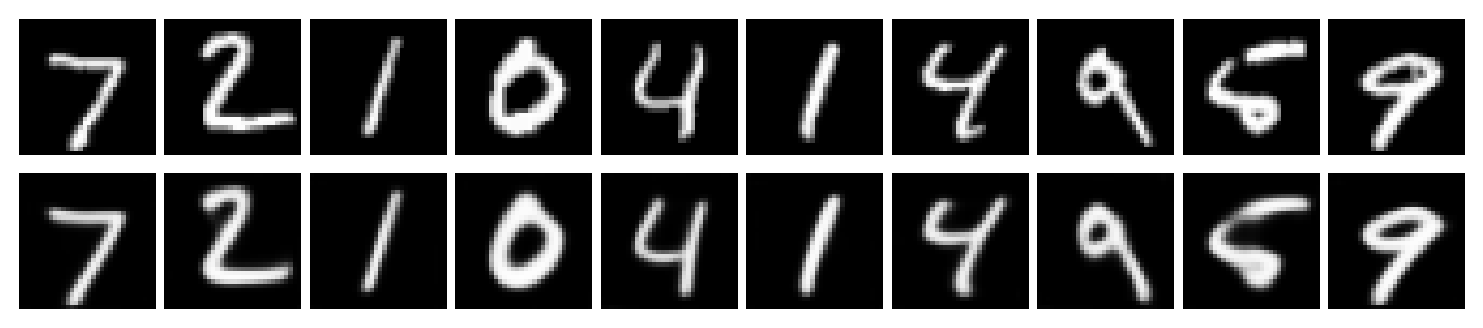

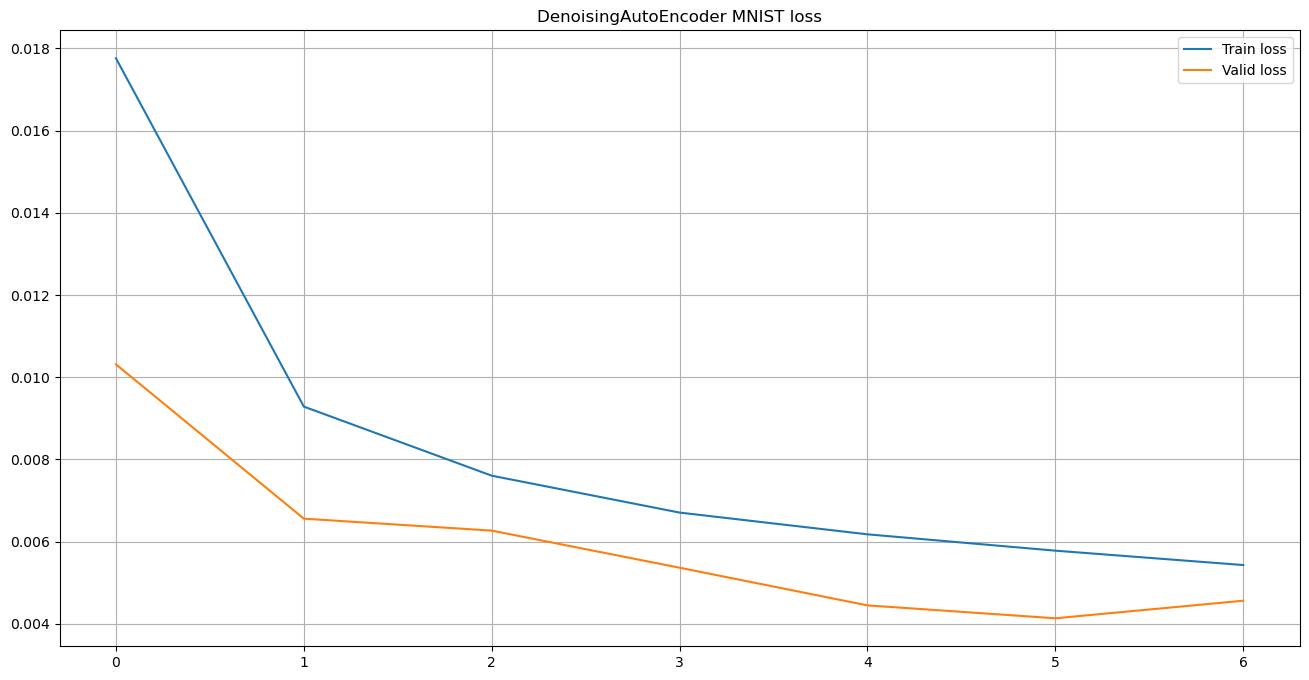

In [94]:
whole_train_valid_cycle(model, 7, 'DenoisingAutoEncoder MNIST')

In [95]:
#!g1.1
@torch.inference_mode()
def get_latent_labels(model, loader, count: int=None):
    model.eval()
    
    total = 0
    
    latent = []
    labels = []
    
    for x, y in loader:
        z = model.encode(x.to(device)).cpu()
        
        latent.append(z)
        labels.append(y)
        
        total += y.shape[0]
        
        if count is not None and total >= count:
            break
            
    latent = torch.cat(latent)[:count].numpy()
    labels = torch.cat(labels)[:count].numpy()
    
    return latent, labels

#!g1.1
x, y = get_latent_labels(model, train_loader, 1000)

#!g1.1
x.shape, y.shape

#!g1.1
from sklearn.ensemble import RandomForestClassifier

#!g1.1
clf = RandomForestClassifier(random_state=0).fit(x, y)

#!g1.1
x_valid, y_valid = get_latent_labels(model, valid_loader)

#!g1.1
(clf.predict(x_valid) == y_valid).mean()

C:\Users\olegs\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


0.9357

In [96]:
model.eval()

x_train, y_train = get_latent_labels(model, train_loader, 1000)
x_valid, y_valid = get_latent_labels(model, valid_loader)

In [98]:
x_train = torch.tensor(x_train)
y_train = torch.tensor(y_train)

x_valid = torch.tensor(x_valid)
y_valid = torch.tensor(y_valid)

In [99]:
print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)

torch.Size([1000, 128]) torch.Size([1000])
torch.Size([10000, 128]) torch.Size([10000])


In [100]:
save_embeddings(x_train, y_train, x_valid, y_valid)